# **Beer analysis via k-means clustering**
Source data: https://www.kaggle.com/datasets/ruthgn/beer-profile-and-ratings-data-set?select=beer_profile_and_ratings.csv

This project aimed to enhance the usability of a dataset containing over 3000 beers (linked above), via a k-means clustering algorithm. It was completed as part of my Data Science BSc, forming part of my first year assessment.

The project included the cleaning and auditing of the source data, exploratory data analysis and visualisation, and modelling of the data. This notebook was accompanied with a detailed project report, including use cases for this work, potential restrictions and future recommendations.

# **1. Data preparation**

### Load the data
The data was downloaded from Kaggle and imported into Google Colab. Required Python libraries were also imported.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
warnings.filterwarnings("ignore")
from google.colab import drive
drive.mount('/content/gdrive') # Connect to Google Drive to load the data

beer = pd.read_csv('/content/gdrive/MyDrive/Training + learning/Data Science apprenticeship degree/Modules/M5/k-means_public_dataset/beer_profile_and_ratings.csv')
print(beer.head()) # Initial check of the data

Mounted at /content/gdrive
                           Name    Style  \
0                         Amber  Altbier   
1                    Double Bag  Altbier   
2                Long Trail Ale  Altbier   
3                  Doppelsticke  Altbier   
4  Sleigh'r Dark Doüble Alt Ale  Altbier   

                                            Brewery  \
0                               Alaskan Brewing Co.   
1                            Long Trail Brewing Co.   
2                            Long Trail Brewing Co.   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Uerige   
4                           Ninkasi Brewing Company   

                                    Beer Name (Full)  \
0                  Alaskan Brewing Co. Alaskan Amber   
1                  Long Trail Brewing Co. Double Bag   
2              Long Trail Brewing Co. Long Trail Ale   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...   
4  Ninkasi Brewing Company Sleigh'r Dark Doüble A...   

                                        

### Data cleaning

Before any analysis or modelling could begin, the data needed to be cleaned and transformed. Firstly, it was assessed for duplicates.

In [2]:
duplicate_name = beer.duplicated('Name').sum() # Count the number of duplicate rows in 'Name'
print(f"Number of duplicates in 'Name': {duplicate_name}")
duplicate_name_full = beer.duplicated('Beer Name (Full)').sum() # Count the number of duplicate rows in 'Beer Name (Full)'
print(f"Number of duplicates in 'Beer Name (Full)': {duplicate_name_full}")

Number of duplicates in 'Name': 131
Number of duplicates in 'Beer Name (Full)': 0


The 'Name' value was found to contain non-unique values, whereas 'Beer Name (Full)' contained no repeated values. Therefore, the 'Name' column was dropped, and the 'Beer Name (Full)' column was renamed to 'Beer Name'.

In [3]:
columns_to_drop = ['Name'] # Specify then delete unnecessary columns
beer = beer.drop(columns_to_drop, axis=1)
beer.rename(columns={'Beer Name (Full)': 'Beer Name'}, inplace=True)
print(beer.head()) # Check the data is as expected

     Style                                           Brewery  \
0  Altbier                               Alaskan Brewing Co.   
1  Altbier                            Long Trail Brewing Co.   
2  Altbier                            Long Trail Brewing Co.   
3  Altbier  Uerige Obergärige Hausbrauerei GmbH / Zum Uerige   
4  Altbier                           Ninkasi Brewing Company   

                                           Beer Name  \
0                  Alaskan Brewing Co. Alaskan Amber   
1                  Long Trail Brewing Co. Double Bag   
2              Long Trail Brewing Co. Long Trail Ale   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...   
4  Ninkasi Brewing Company Sleigh'r Dark Doüble A...   

                                         Description  ABV  Min IBU  Max IBU  \
0  Notes:Richly malty and long on the palate, wit...  5.3       25       50   
1  Notes:This malty, full-bodied double alt is al...  7.2       25       50   
2  Notes:Long Trail Ale is a full-bodied 

The datatypes of each column were assessed and found to be correct:

In [4]:
print(beer.info()) # Check the data types are correct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Style              3197 non-null   object 
 1   Brewery            3197 non-null   object 
 2   Beer Name          3197 non-null   object 
 3   Description        3197 non-null   object 
 4   ABV                3197 non-null   float64
 5   Min IBU            3197 non-null   int64  
 6   Max IBU            3197 non-null   int64  
 7   Astringency        3197 non-null   int64  
 8   Body               3197 non-null   int64  
 9   Alcohol            3197 non-null   int64  
 10  Bitter             3197 non-null   int64  
 11  Sweet              3197 non-null   int64  
 12  Sour               3197 non-null   int64  
 13  Salty              3197 non-null   int64  
 14  Fruits             3197 non-null   int64  
 15  Hoppy              3197 non-null   int64  
 16  Spices             3197 

The data contained no personally identifiable information (PII) or other sensitive data, which would potentially have needed to be masked or removed. Therefore, the cleaning of the data was complete.

### Data quality audit
Next, a data quality audit was conducted on the data. The 6 dimensions of data quality were used as a framework for this.

Accuracy, consistency and timeliness were not applicable to this particular use case, as it was conducted on a static, public dataset for learning purposes.

#### Uniqueness

In [5]:
duplicate_count = beer.duplicated().sum() # Count the number of duplicate rows
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Completeness

In [6]:
print('Count of null values per column')
beer.isnull().sum()

Count of null values per column


,0
Style,0
Brewery,0
Beer Name,0
Description,0
ABV,0
Min IBU,0
Max IBU,0
Astringency,0
Body,0
Alcohol,0


There were no blank fields in the data. However, from reviewing the original data table, it was noticed that many of the "Description" values only contained the string "Notes:" with no further content. These values can therefore be assumed empty, or null.

In [7]:
print("Number of rows that only contain 'Notes:' in the Description column:")
beer['Description'].value_counts()["Notes:"]

Number of rows that only contain 'Notes:' in the Description column:


1347

####Validity

The ABV and taste variables were checked for outliers or other unexpected values using box plots.

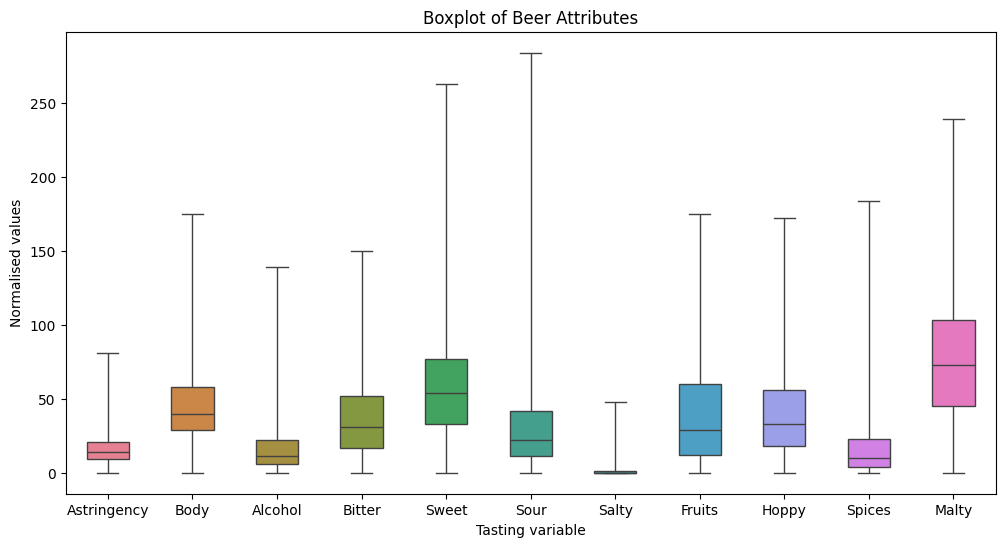

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6)) # Set the figure size
sns.boxplot(data=beer[['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']], whis=(0, 100), width=.5)
plt.title('Boxplot of Beer Attributes')
plt.xlabel('Tasting variable')
plt.ylabel('Normalised values')
plt.show()

All boxplots indicated statistical outliers. Upon investigation, the outliers in the taste variables were deemed to be within an acceptable range and were therefore not classed as errors.
However, the outliers in the ABV column were more concerning. An upper threshold for this column was set at 20, and any rows below this value were removed. (Had this project been a genuine business case, a more thorough investigation would have been instigated to determine what is a truly acceptable upper limit for ABV).

In [9]:
# Drop rows where ABV is greater than 20
beer = beer[beer['ABV'] <= 20]

### Feature Engineering

The 'Style' column (categorical values) was checked to assess the format of the values, and to ensure there were no obvious errors. This identified that the values were made of two components, representing two levels of categorisation, split by a dash:

In [10]:
print("\nStyle")
for index, value in beer['Style'].value_counts().items():
    print("\t",index, value)
print("\t","null", beer['Style'].isna().sum())


Style
	 Lager - Adjunct 45
	 Lager - European Pale 43
	 Wheat Beer - Hefeweizen 42
	 Stout - Irish Dry 42
	 Lambic - Fruit 42
	 Bitter - English 41
	 Strong Ale - Belgian Dark 41
	 Dubbel 41
	 Winter Warmer 40
	 Brown Ale - English 40
	 Strong Ale - Belgian Pale 40
	 Pale Ale - English 40
	 Bock - Doppelbock 40
	 Lager - Light 40
	 Lager - Märzen / Oktoberfest 39
	 Lager - European Strong 39
	 Altbier 39
	 IPA - American 38
	 Pilsner - German 38
	 Barleywine - American 38
	 Red Ale - Irish 38
	 IPA - English 37
	 Porter - English 37
	 Lager - Vienna 37
	 Fruit and Field Beer 37
	 Wheat Beer - Dunkelweizen 37
	 Tripel 37
	 Lager - Munich Dunkel 36
	 Stout - Foreign / Export 36
	 Lager - Helles 36
	 Wheat Beer - Witbier 36
	 Porter - American 36
	 Strong Ale - English 35
	 IPA - Imperial 35
	 Scotch Ale / Wee Heavy 35
	 Stout - Russian Imperial 35
	 Bock - Maibock 35
	 Lager - European / Dortmunder Export 35
	 Quadrupel (Quad) 34
	 Lager - American Amber / Red 34
	 Old Ale 34
	 Scottish

It was therefore decided to split the 'Style' column based on the dash delimiter, to create two new columns: 'Style - level 1' and 'Style - level 2'. This would facilitate better analysis later on. The original column was then dropped.

In [11]:
beer[['Style 1','Style 2']] = beer['Style'].str.split(' - ',expand=True) # Split the Style column

# Drop the Style column
drop_columns = ['Style']
beer = beer.drop(drop_columns, axis=1)

# Move the new columns in the dataframe
style_1 = beer.pop('Style 1')
beer.insert(2, 'Style 1', style_1)
style_2 = beer.pop('Style 2')
beer.insert(3, 'Style 2', style_2)

print(beer.head())

                                            Brewery  \
0                               Alaskan Brewing Co.   
1                            Long Trail Brewing Co.   
2                            Long Trail Brewing Co.   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Uerige   
4                           Ninkasi Brewing Company   

                                           Beer Name  Style 1 Style 2  \
0                  Alaskan Brewing Co. Alaskan Amber  Altbier    None   
1                  Long Trail Brewing Co. Double Bag  Altbier    None   
2              Long Trail Brewing Co. Long Trail Ale  Altbier    None   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...  Altbier    None   
4  Ninkasi Brewing Company Sleigh'r Dark Doüble A...  Altbier    None   

                                         Description  ABV  Min IBU  Max IBU  \
0  Notes:Richly malty and long on the palate, wit...  5.3       25       50   
1  Notes:This malty, full-bodied double alt is al...  7.2       25      

# **2. Exploratory Data Analysis, EDA**

#### Summary metrics
Firstly, the summary metrics for all columns were investigated, to better understand the data.

In [12]:
beer.describe(include='all')

,Brewery,Beer Name,Style 1,Style 2,Description,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
count,3194,3194,3194,2516,3194,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000,3194.000000
unique,934,3194,43,63,1840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Boston Beer Company (Samuel Adams),Alaskan Brewing Co. Alaskan Amber,Lager,English,Notes:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,39,1,567,284,1345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,6.496387,21.172198,38.970257,16.527552,46.155291,17.042267,36.387602,58.283970,33.167188,1.018159,38.535692,40.958359,18.347840,75.363807,3.638308,3.754100,3.660032,3.702070,3.747421,233.392298
std,NaN,NaN,NaN,NaN,NaN,2.312742,13.243927,21.337769,10.407995,25.940541,17.319471,25.789083,34.266862,35.789519,2.133425,32.297118,30.397458,23.760936,39.887421,0.503158,0.403482,0.449949,0.510213,0.444417,361.928667
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.509615,1.571429,1.285714,1.214286,1.136364,1.000000
25%,NaN,NaN,NaN,NaN,NaN,5.000000,15.000000,25.000000,9.000000,29.000000,6.000000,17.000000,33.000000,11.000000,0.000000,12.000000,18.000000,4.000000,45.000000,3.422046,3.604651,3.469778,3.500000,3.567019,23.000000
50%,NaN,NaN,NaN,NaN,NaN,6.000000,20.000000,35.000000,14.000000,40.500000,11.000000,31.000000,54.000000,22.000000,0.000000,29.000000,33.000000,10.000000,73.000000,3.719905,3.833333,3.741452,3.791667,3.830192,93.000000
75%,NaN,NaN,NaN,NaN,NaN,7.600000,25.000000,45.000000,21.750000,58.000000,22.000000,52.000000,77.000000,42.000000,1.000000,60.000000,56.000000,23.000000,102.750000,3.977145,4.000000,3.964800,4.032914,4.032706,284.000000


##### Observations


*   There are 4 categorical variables. 'Beer Name (Full)' and 'Description' are unstructured, and contain unique (non duplicate) values. The 2 'Style' variables are more structured, and contain fewer unique values. Whilst none of the categorical values are approproate for the k-means clustering (without further transformation, such as one-hot encoding), they may be useful for further analysis later on.
*   All other variables are numerical. The numerical values will henceforth be referred to as 'Basic variables' (ABV, Min IBU and Max IBU), 'Review variables' (review_aroma, review_appearance, review_palate, review_taste and review_overall), and 'Taste variables' (all other numerical columns).
*   The 'Style 1' column contains 43 unique values. This is far more digestible and useful for visualisation and analysis than the original 'Style' column that was split out in the previous steps.
*   The ranges of the taste variables differs between columns, for example 'Astringency' has a range 0-100, whereas 'Sour' ranges from 0-284. The data will therefore need normalising before the k-means clustering can be run.
*   The standard deviations vary notably between taste variables. Malty has the highest standard deviation (39.9), indicating a high spread of scores. Salty has a low standard deviation (2.1), and also a low maximum value (48), indicating the beers are all generally low saltiness, with little deviation in this metric between them.
*   The ABV range has a minimum of 0, indicating that alcohol-free beers are included in this data.
*   The reviews are scored on a 0-5 scale. They all have a mean average of approximately 3.7.



### Scatter plots and pairplot

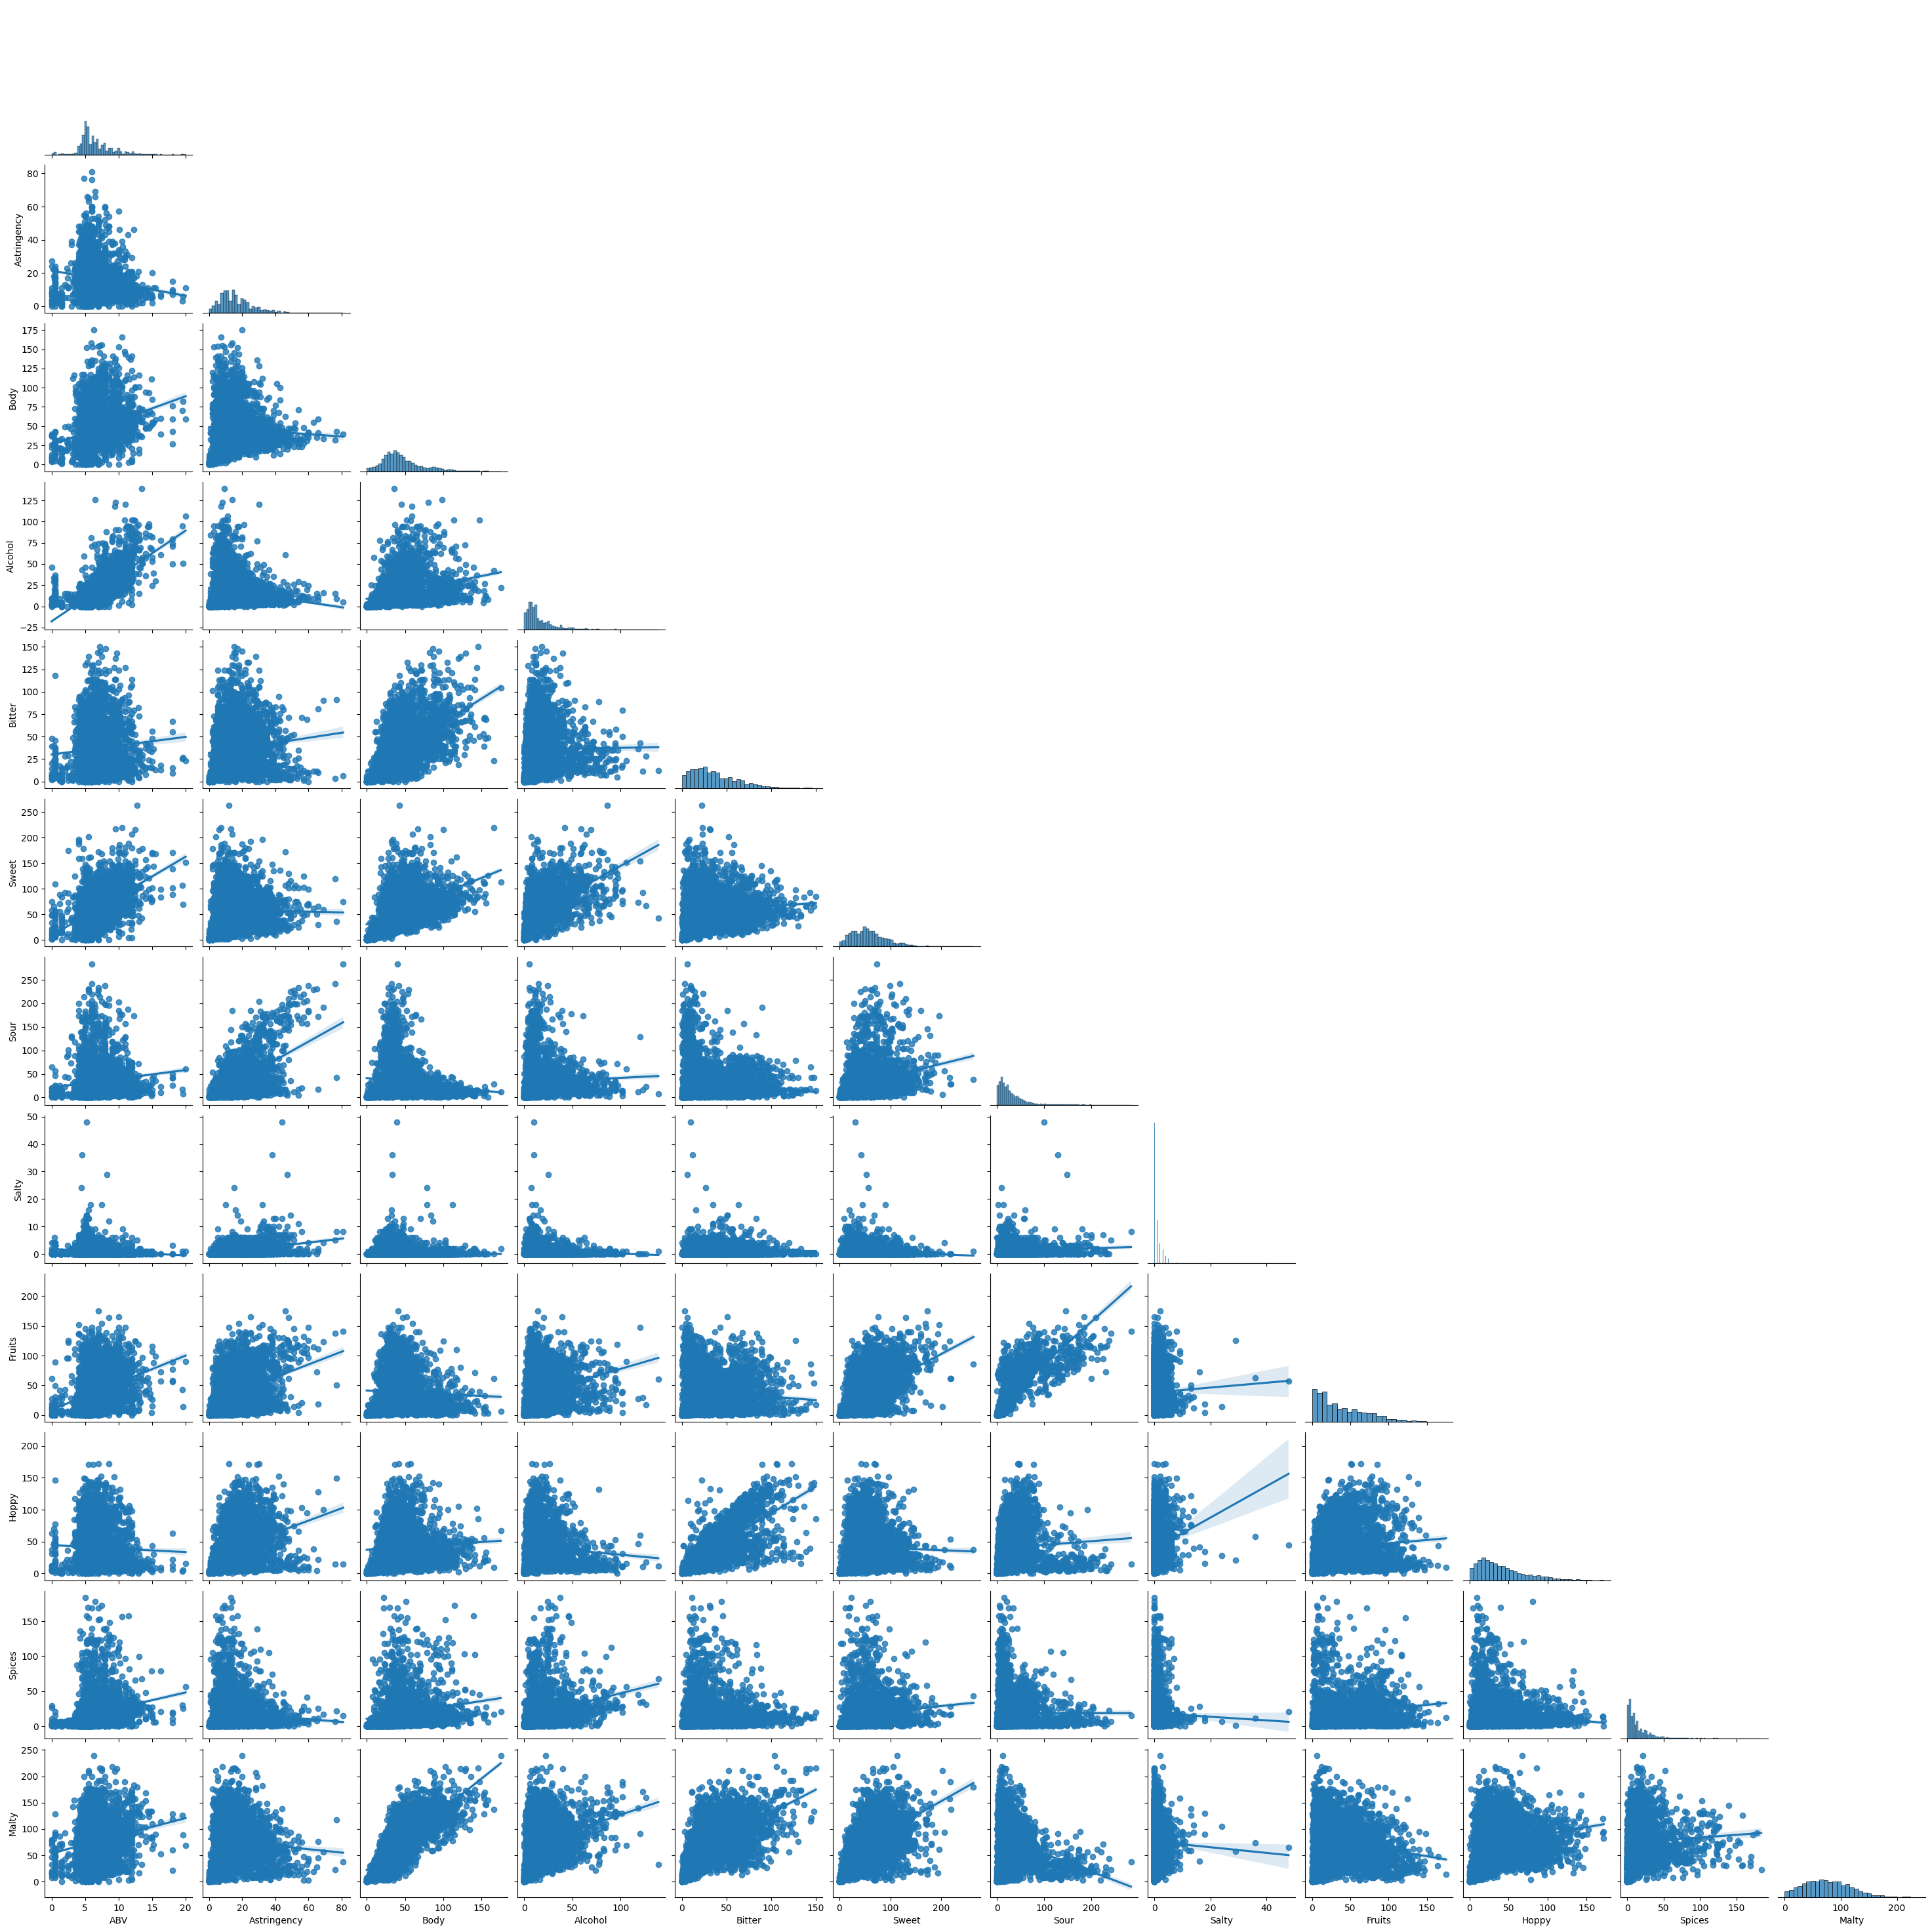

In [13]:
sns.pairplot(beer, vars=['ABV', 'Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty'], diag_kind='hist', corner=True, kind='reg')

### Correlation matrix
A correlation matrix of the taste variables was plotted to assess potential multicollinearity amongst the data.

Text(0.5, 1.0, 'Correlation between all taste variables')

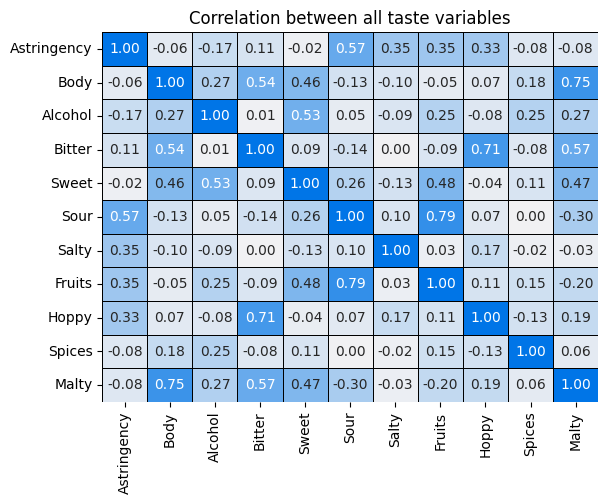

In [14]:
# Select the relevant columns
beer_subset = beer[['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']]

# Define the correlation matrix
correlation_matrix = beer_subset.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, linecolor='black', cbar=False, cmap=sns.diverging_palette(255,255, s=100, as_cmap=True))
plt.title("Correlation between all taste variables")

Text(0.5, 1.0, 'Scatter plot of Fruits and Sour variables')

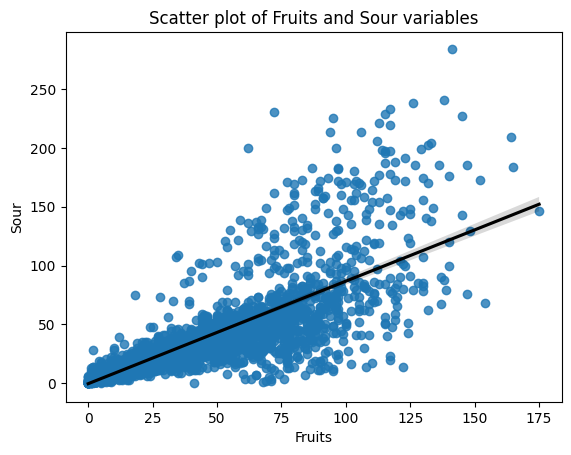

In [15]:
sns.regplot(x = beer['Fruits'], y = beer['Sour'],
            line_kws = {"color": "black"},).set_title('Scatter plot of Fruits and Sour variables')

Text(0.5, 1.0, 'Scatter plot of Body and Malty variables')

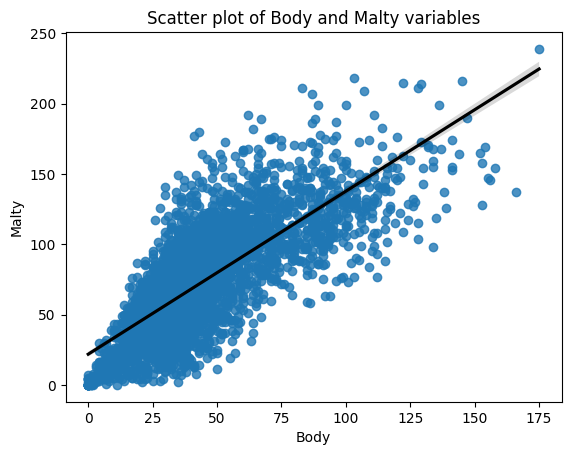

In [16]:
sns.regplot(x = beer['Body'], y = beer['Malty'],
            line_kws = {"color": "black"},).set_title('Scatter plot of Body and Malty variables')

##### Observations
Almost all variables displayed very little correlation with each other. The only variables showing a very strong correlation (>0.7) were:

*   Hoppy/Bitter
*   Fruits/Sour
*   Body/Malty

These are all unsurprising correlations. Given that the definitions of these correlating variables are distinct, despite their high correlation, it was decided to leave them in the dataset.

### Tree map of beer ratings
A tree chart was plotted to assess the review scores across each style of beer (Style - level 1). The size of the outer boxes represents the number of reviews that style has, and the colours correspond to the average scores of those reviews.

Treemaps are a space-efficient way to visually represent trends and quantities. They also allow the nesting of variables, so multiple values can be compared concurrently (in this case, beer styles and individual beers).
The treemap is logically colour coded (blue-red, representing high-low ratings), and detailed data labels are removed to avoid visual clutter.


In [17]:
import plotly.express as px
import numpy as np

beer_tree = beer.copy()
beer_tree['Overall review'] = beer_tree['review_overall']

fig_tree_weights = px.treemap(beer_tree, path=['Style 1'],
                      values = 'number_of_reviews',
                      color='Overall review',
                      color_continuous_scale='RdBu',
                      color_continuous_midpoint=np.average(beer_tree['Overall review'], weights=beer_tree['number_of_reviews']),
                      range_color=[1, 5],
                      title = 'Beer reviews by style',

                     )

fig_tree_weights.update_layout(
    autosize=True,
    hovermode='closest',
    width=1300,
    height=1000,
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(t=70, b=15, l=0, r=0))

fig_tree_weights.update_layout(
    coloraxis_showscale=True)
fig_tree_weights.update_layout(
    title=dict(font=dict(size=30)))

fig_tree_weights.update_traces(root_color="white")

#fig_tree_weights.update_layout(
    #uniformtext=dict(minsize=12, mode='show'))

fig_tree_weights.show()

#### Observations

*   Lager has the most reviews, and those reviews are generally quite poor compared to the other styles.
*   IPA, stout and strong ale also have a fairly large quantity of reviews, and generally score higher than lager.
*   Of the beers that have had fewer reviews, fruit and field beer, pumpkin beer, cream ale and low alcohol beer all have notably low reviews.
*   Wild ale has the highest overall review score at 4.27, although this is from a relatively low quantity of reviews.
*   Low alcohol beer has the lowest overall review score at 2.56, although this is from a relatively low quantity of reviews.



# **3. K-means clustering**

The clustering model **is** intended to segment the beers into discrete types, based on their flavour profile. Therefore, the 11 taste variables were chosen to be used as input variables in the k-means clusering algorithm. ABV, Min IBU and Max IBU and the review variables are not as directly related to taste profiles.

Therefore, the variables selected for the k-means clustering model were:

'Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty'

### **Data transformation**

Before the model could be run, the input variables needed to be normalised. This ensures that no single variable is given disproprortionate emphasis in the modelling process, due to differences in scale between the variables.

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Transform the selected columns into normalised values
beer_normalised = beer.copy()
beer_normalised[['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']] = scaler.fit_transform(beer[['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']])

# Print the transformed dataset
beer_normalised.loc[:,['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']].head()

,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
0,0.160494,0.182857,0.064748,0.313333,0.281369,0.116197,0.000000,0.188571,0.331395,0.043478,0.464435
1,0.148148,0.325714,0.129496,0.220000,0.209125,0.056338,0.000000,0.137143,0.203488,0.065217,0.351464
2,0.172840,0.211429,0.043165,0.280000,0.163498,0.038732,0.000000,0.057143,0.313953,0.021739,0.259414
3,0.160494,0.314286,0.223022,0.313333,0.384030,0.063380,0.020833,0.280000,0.232558,0.086957,0.497908
4,0.308642,0.291429,0.187050,0.293333,0.171103,0.031690,0.020833,0.062857,0.296512,0.108696,0.397490


Principal component analysis (PCA) was used to reduce the dimensionality from 11 features into 3 dimensions. This helped mitigate the “curse of dimensionality”, reduced computational expense, and enabled better cluster visualisation.

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

x = beer_normalised.loc[:,['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']]

principalComponents = pca.fit_transform(x)

beer_reduced = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2', 'PC3'])
print(beer_reduced.head())

        PC1       PC2       PC3
0  0.128353 -0.023078 -0.057715
1  0.031783 -0.121494  0.054670
2  0.005358 -0.176830 -0.160230
3  0.193721  0.051752  0.166628
4  0.130911 -0.121983 -0.049607


### **Decide the number of clusters (k)**

With the data prepared, the next step was to decide on the k-value (the number of clusters). The k-value needed to be as small as possible, without losing quality or differentiation between the resulting clusters. To help decide, distortion scores at multiple k-values were plotted, and the 'elbow method' was used to determine the optimal value.

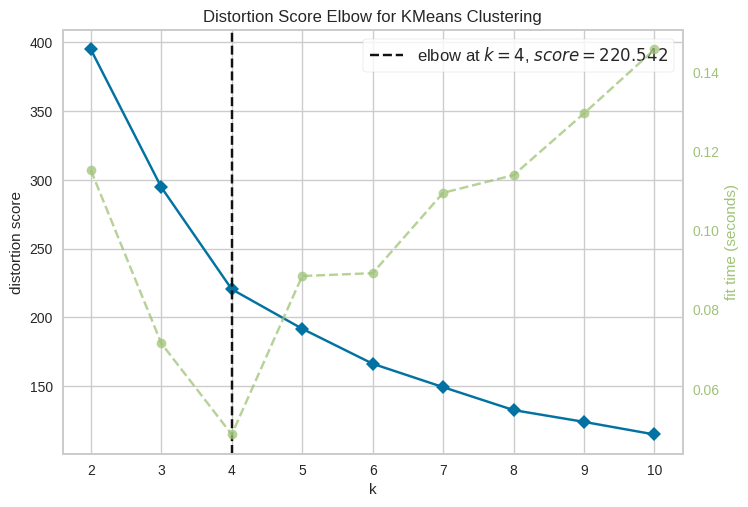

In [20]:
# Create a new dataframe with the input variables as the only columns
model_data = beer_reduced

from yellowbrick.cluster import KElbowVisualizer

# Plot an elbow curve across multiple k values
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(model_data)
Elbow_M.show();

#### Observations

*   The elbow appears at k=4.
*   After this point, there is little improvement in distortion score as k increases.
*   The fit time steadily increases after k=3.

4 is a suitable number of clusters for this particular project, therefore k=4 was selected.

### **Run the k-means clustering model**

The k-means model was run, and the resulting cluster labels (0, 1, 2, 3) were appended to the original dataset as a new column.

In [21]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# Initialize the model with 4 clusters (k=4)
km = KMeans(n_clusters=4, init='k-means++', max_iter=600, n_init=10)

# Fit the model to the data
km.fit(model_data)

# Add a new column containing the cluster labels
model_data['cluster'] = km.labels_

print(model_data.head())

        PC1       PC2       PC3  cluster
0  0.128353 -0.023078 -0.057715        1
1  0.031783 -0.121494  0.054670        1
2  0.005358 -0.176830 -0.160230        2
3  0.193721  0.051752  0.166628        1
4  0.130911 -0.121983 -0.049607        1


In [22]:
# Merge the two dataframes
beer_clustered = pd.merge(beer, model_data, left_index=True, right_index=True, how='inner')
columns_to_drop = ['PC1','PC2','PC3'] # Specify then delete unnecessary columns
beer = beer_clustered.drop(columns_to_drop, axis=1)


# Print the merged dataframe
print(beer_clustered.head())

                                            Brewery  \
0                               Alaskan Brewing Co.   
1                            Long Trail Brewing Co.   
2                            Long Trail Brewing Co.   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Uerige   
4                           Ninkasi Brewing Company   

                                           Beer Name  Style 1 Style 2  \
0                  Alaskan Brewing Co. Alaskan Amber  Altbier    None   
1                  Long Trail Brewing Co. Double Bag  Altbier    None   
2              Long Trail Brewing Co. Long Trail Ale  Altbier    None   
3  Uerige Obergärige Hausbrauerei GmbH / Zum Ueri...  Altbier    None   
4  Ninkasi Brewing Company Sleigh'r Dark Doüble A...  Altbier    None   

                                         Description  ABV  Min IBU  Max IBU  \
0  Notes:Richly malty and long on the palate, wit...  5.3       25       50   
1  Notes:This malty, full-bodied double alt is al...  7.2       25      

The number of rows per cluster was plotted, and showed a fairly even spread of 600-1000 beers per cluster.

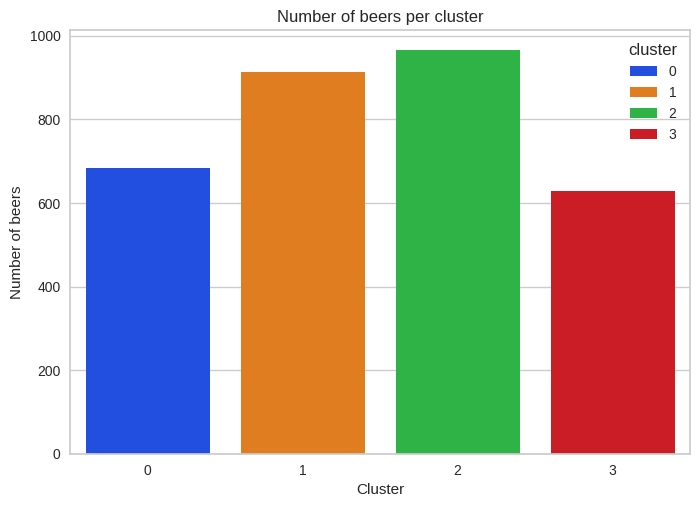

cluster
0    684
1    913
2    965
3    629
Name: Beer Name, dtype: int64


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar chart of the cluster sizes
sns.countplot(x='cluster', data=beer_clustered, hue='cluster', palette='bright')
plt.title('Number of beers per cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of beers')
plt.show()

# Count of rows, split by cluster
print(beer_clustered.groupby('cluster')['Beer Name'].count())

The clusters were plotted against the 3 principle components. A clear distinction can be seen between the clusters.

In [24]:
fig = px.scatter_3d(model_data, x='PC1', y='PC2', z='PC3',
                    color='cluster', opacity=0.7, title='3D Scatter Plot of Clusters')

fig.show()

# **4. Analysis of the clusters**

### Pairplot

A pairplot was created as an easy way to visualise general trends of the clusters across the variables, and ensure clear differentiation.

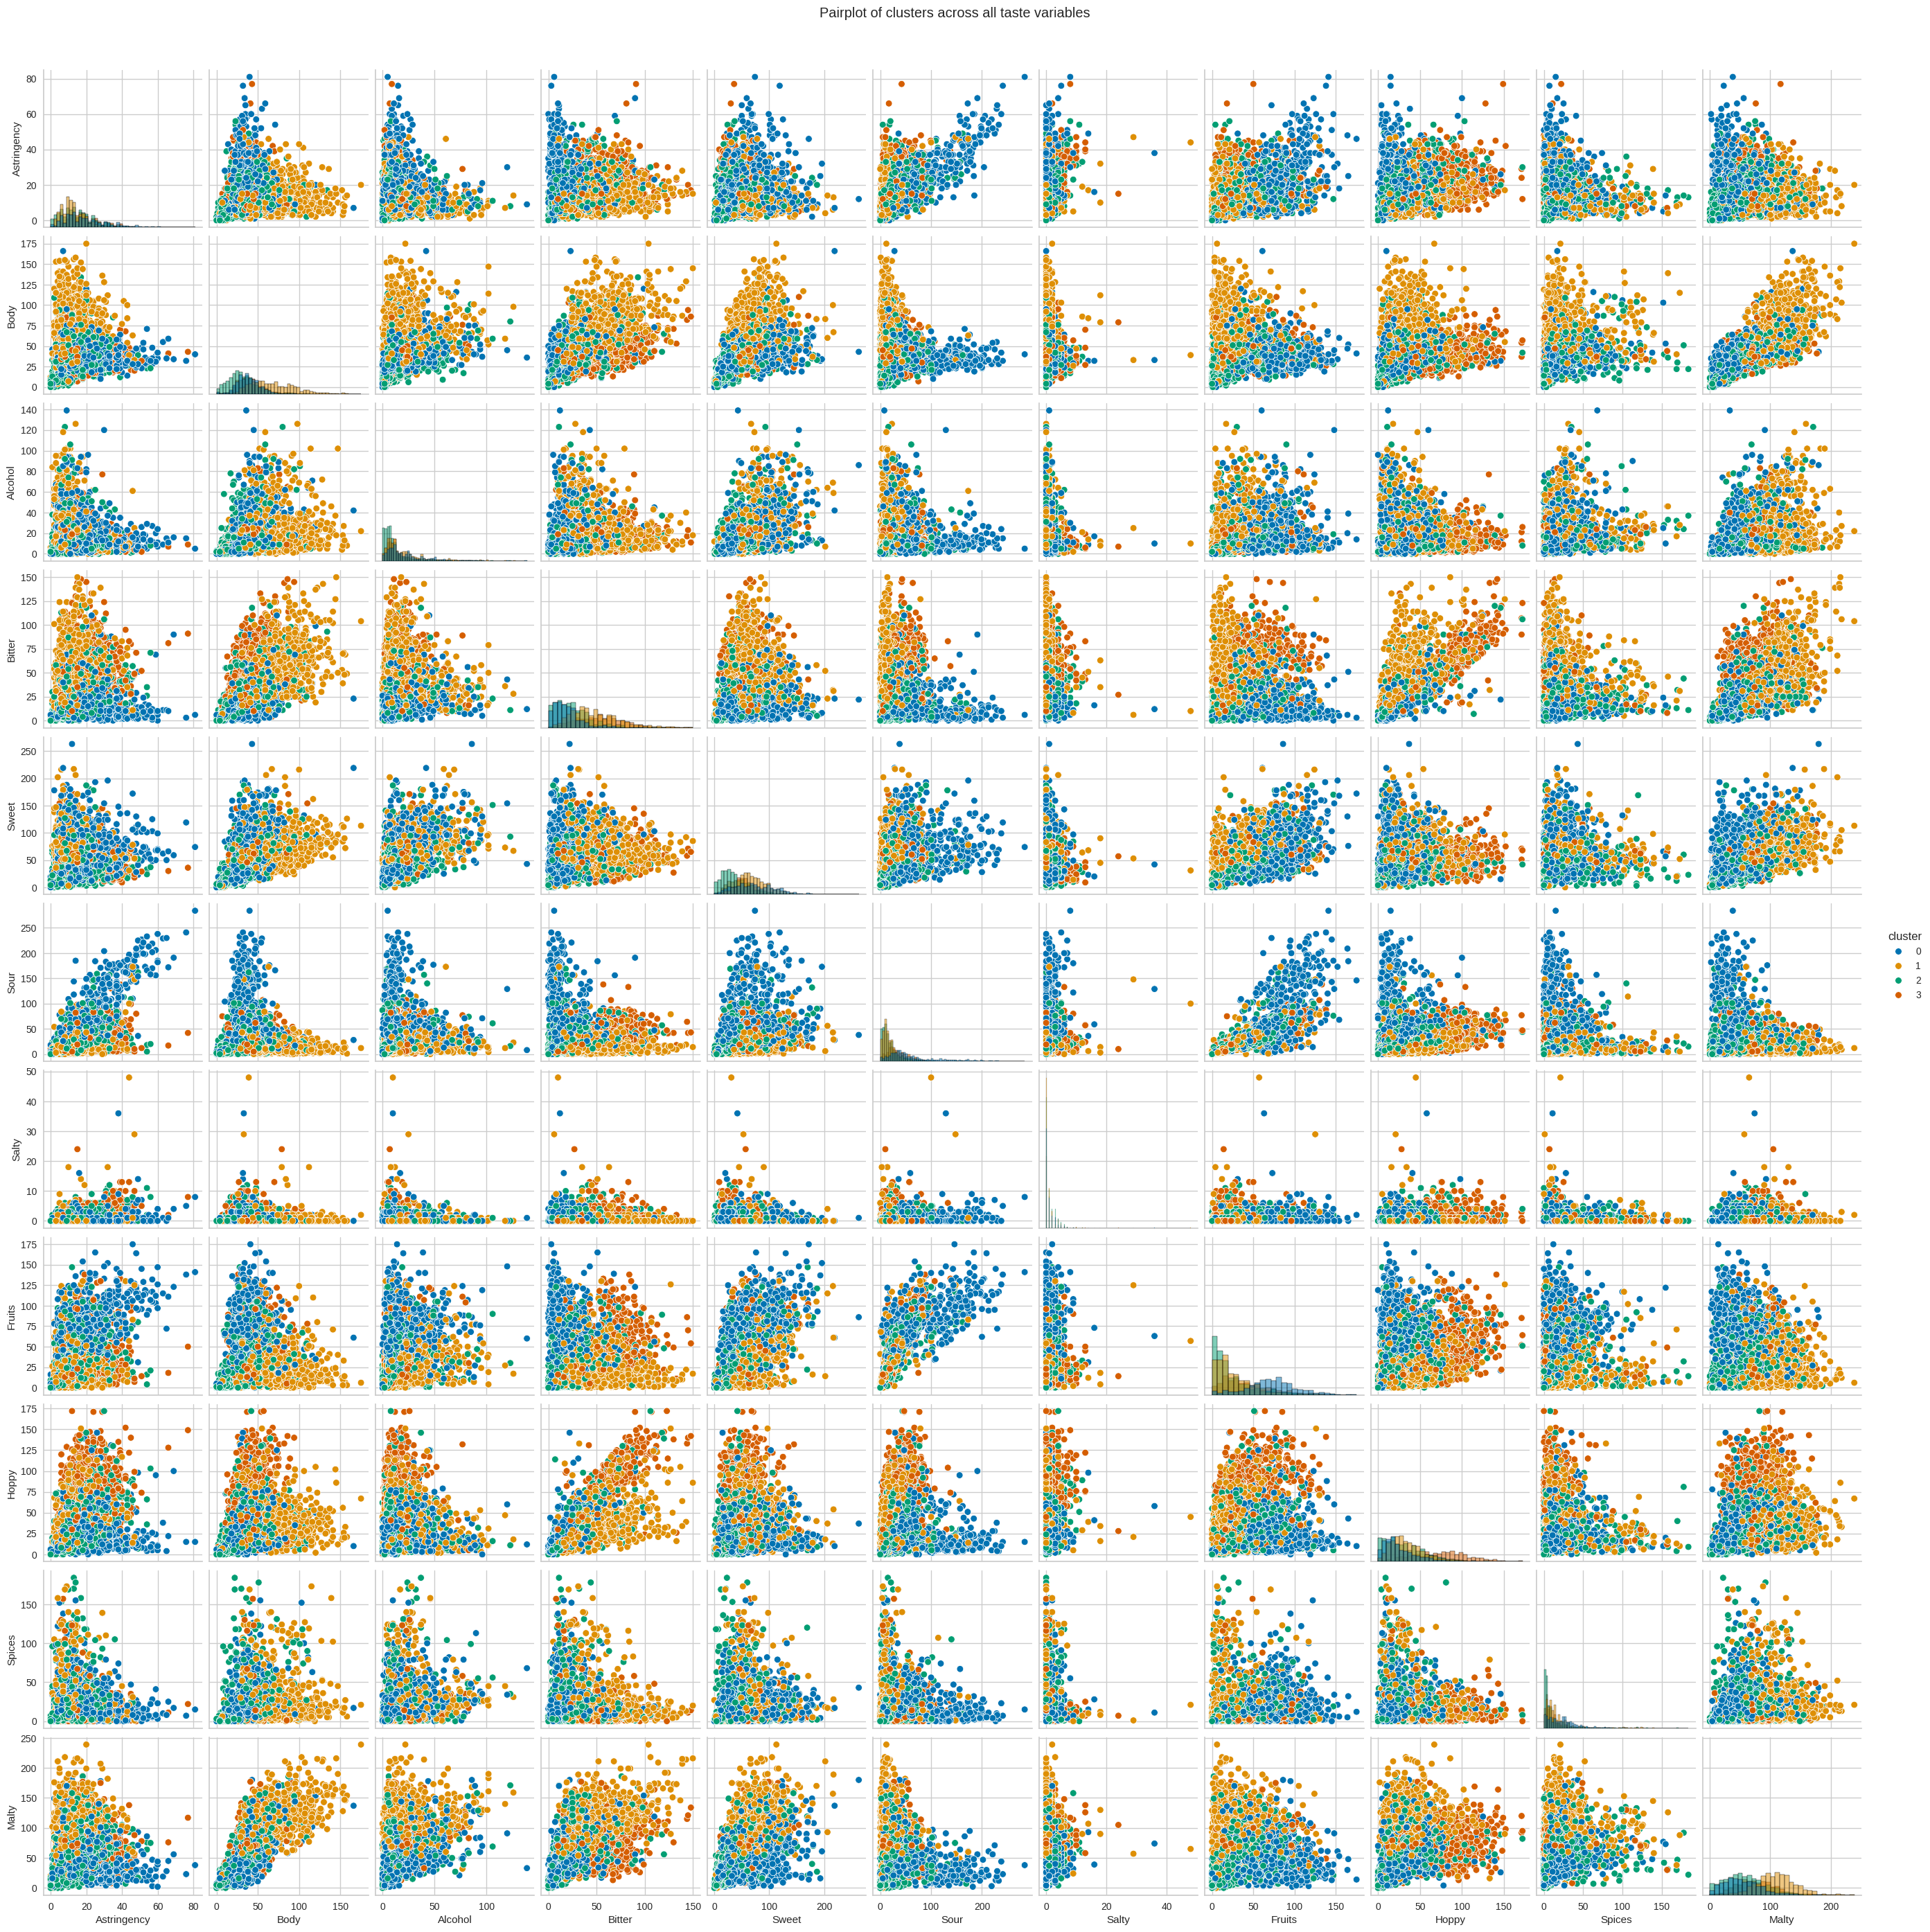

In [25]:
sns.pairplot(beer_clustered, vars=['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty'], hue='cluster', palette='colorblind', diag_kind='hist')
plt.suptitle('Pairplot of clusters across all taste variables', y=1.02)
plt.show()

#### Observations


*   There is clear grouping and differentiation of the clusters across most combinations of variables, indicating well defined, distinct groupings of beers.
*   Some patterns are immediately clear even from this high-level view, for example Cluster 0 is displaying high levels of 'Hoppy' and 'Bitter' notes, but low 'Spices'. Cluster 2, however, appears to have high 'Sour' and 'Fruits' notes, but low 'Hoppy', 'Spices' and 'Malty'. These patterns will be investigated further.

### Average taste metrics across segments

A basic table containing average values per cluster for each taste variable was plotted, to start defining the unique taste profiles of each cluster. A heatmap gradient was applied for easier trend visualisation.

In [26]:
beer_avgs = beer.groupby('cluster')[['Astringency', 'Body', 'Alcohol', 'Bitter', 'Sweet', 'Sour', 'Salty', 'Fruits', 'Hoppy', 'Spices', 'Malty']].mean().style.background_gradient(cmap='Blues')
beer_avgs

,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
cluster,,,,,,,,,,,
0,20.013158,39.672515,22.437135,19.907895,74.190058,66.744152,0.938596,72.204678,27.761696,25.767544,53.918129
1,12.990142,68.698795,20.980285,48.200438,71.227820,18.696605,0.692223,26.409639,36.363636,20.646221,109.266156
2,15.113990,32.814508,11.783420,25.216580,39.980311,21.480829,1.113990,23.986528,32.586528,14.996891,58.718135
3,20.076312,40.963434,13.413355,54.311606,50.248013,35.591415,1.435612,41.806041,74.783784,11.755167,75.023847


#### Observations
*(note: when re-running this script, the cluster numbers may be applied in a different order)*


*   Cluster 0 has high scores for 'bitter' and 'hoppy', and low for 'alcohol' and 'spices'. It also scores the highest for 'salty' across the 4 clusters, though the value is still very low.
*   Cluster 1 scores highly across a number of variables, including 'body', 'alcohol', 'bitter', 'sweet' and 'malty'.
*   Cluster 2 also scores highly across a number of variables, including 'alcohol', 'sweet', 'sour', 'fruits'.
*   Cluster 3 has relatively low scores across all values.

There are clear taste profiles already emerging from this data. It can also be concluded that cluster 3 beers have a more mild/subtle flavour, and clusters 1 and 2 are stronger/richer.

### Boxen plots

To validate the conclusions drawn above, boxen plots for each segment were created across all taste variables. An example is shown below..

These plots did not show any excessive spread or outliers in the data, giving further confidence to the taste profiles that emerged from the table of mean values above.

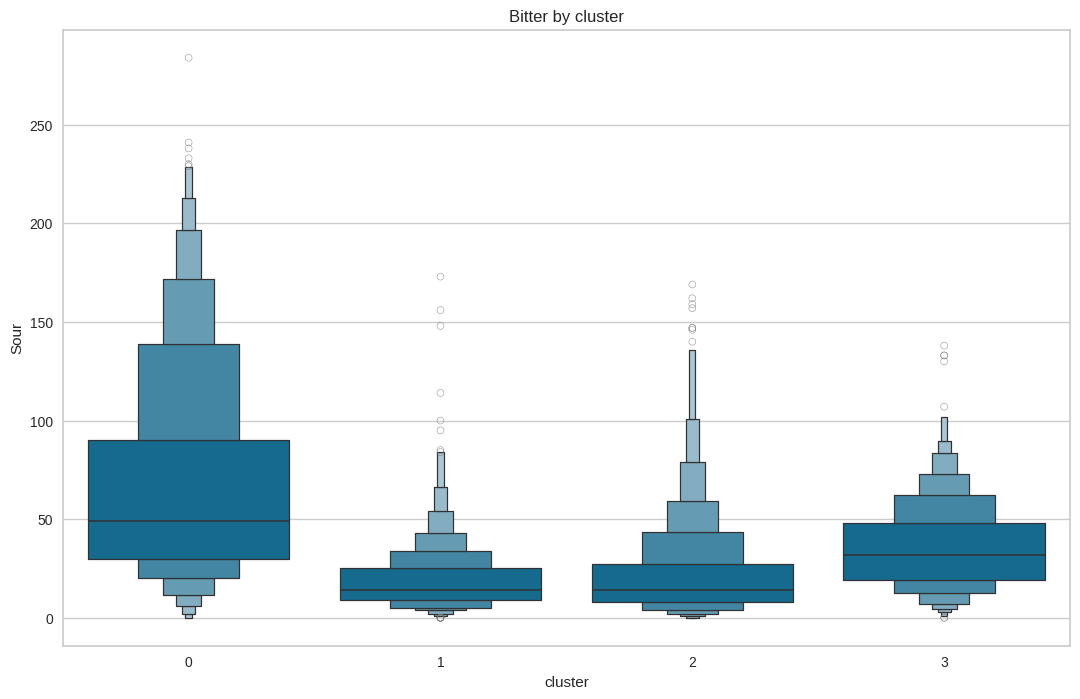

In [27]:
plt.figure(figsize=(13,8))
pl=sns.boxenplot(y=beer['Sour'],x=beer['cluster'])
pl.set_title('Bitter by cluster');

In [28]:
beer_review_avgs = beer.groupby('cluster')[['review_aroma', 'review_appearance', 'review_palate', 'review_taste', 'review_overall']].mean().style.background_gradient(cmap='Blues')
beer_review_avgs

,review_aroma,review_appearance,review_palate,review_taste,review_overall
cluster,,,,,
0,3.838880,3.853349,3.800335,3.868405,3.851165
1,3.787405,3.903028,3.782304,3.854771,3.850261
2,3.324795,3.503326,3.390539,3.398517,3.513480
3,3.684044,3.814692,3.742935,3.765209,3.844433


### Wordclouds

To further understand the clusters, wordclouds were plotted from the descriptions contained in the original dataset.

Generic words such as 'beer' and 'style' were removed from the wordclouds, and they were limited only to the top 20 words to improve legibility.

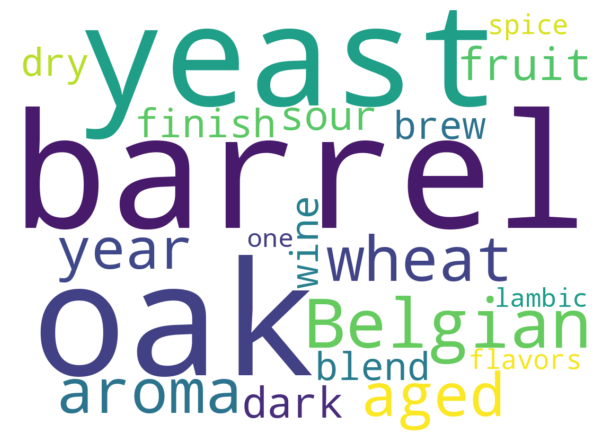

In [29]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter the data to only include rows where the cluster is 0
beer_cluster_0 = beer[beer['cluster'] == 0]

# Define stop words to exclude from the wordcloud
stop_words = ['malt', 'ibu', 'hop', 'hops', 'beer', 'beers', 'taste', 'flavor', 'style', 'Note', 'Notes', 'brewed', 'ale', 'bottle', 'its', 'which', 'you', 's', 'a', 'an', 'and', 'are', 'as', 'at', 'be', 'but', 'by', 'for', 'if', 'in', 'into', 'is', 'it', 'no', 'not', 'of', 'on', 'or', 'such', 'that', 'the', 'their', 'then', 'there', 'these', 'they', 'this', 'to', 'was', 'will', 'with', 't', 'our', 'we', 'has', 'your', 'from']

# Import the shape to use for the wordcloud
from PIL import Image
beer_mask = np.array(Image.open('/content/gdrive/MyDrive/Training + learning/Data Science apprenticeship degree/Modules/M5/k-means_public_dataset/beer-mug-silhouette.jpg'))

# Create a wordcloud of the 'Description' column
wordcloud = WordCloud(stopwords=stop_words, collocations=False, background_color='white', max_words=20, width=1100, height=800,).generate(' '.join(beer_cluster_0['Description']))
# create image as cloud
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
# store to file
plt.show()

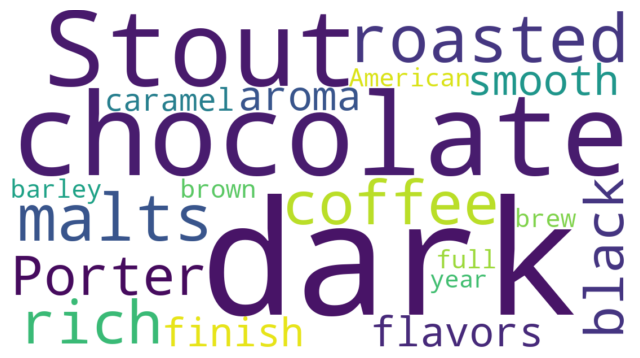

In [30]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter the data to only include rows where the cluster is 0
beer_cluster_1 = beer[beer['cluster'] == 1]

# Create a wordcloud of the 'Description' column
wordcloud = WordCloud(stopwords=stop_words, collocations=False, background_color='white', max_words=20, width=1100, height=600).generate(' '.join(beer_cluster_1['Description']))
# create image as cloud
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
# store to file
plt.savefig("cloud.png", format="png")
plt.show()

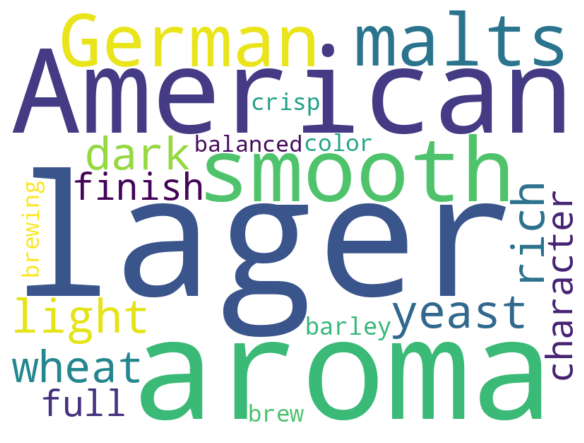

In [31]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter the data to only include rows where the cluster is 0
beer_cluster_2 = beer[beer['cluster'] == 2]

# Create a wordcloud of the 'Description' column
wordcloud = WordCloud(stopwords=stop_words, collocations=False, background_color='white', max_words=20, width=800, height=600).generate(' '.join(beer_cluster_2['Description']))
# create image as cloud
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
# store to file
plt.savefig("cloud.png", format="png")
plt.show()

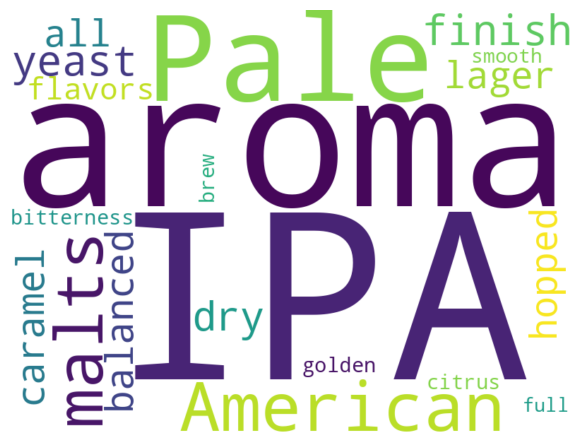

In [32]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter the data to only include rows where the cluster is 0
beer_cluster_3 = beer[beer['cluster'] == 3]

# Create a wordcloud of the 'Description' column
wordcloud = WordCloud(stopwords=stop_words, collocations=False, background_color='white', max_words=20, width=800, height=600).generate(' '.join(beer_cluster_3['Description']))
# create image as cloud
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
# store to file
plt.savefig("cloud.png", format="png")
plt.show()

### Further cluster analysis

In [33]:
# Find the index of the row with the highest 'review_overall' in cluster 1
index_max_review = beer_clustered[beer_clustered['cluster'] == 0]['number_of_reviews'].idxmax()

# Print the details of that row
print(beer_clustered.loc[index_max_review])


Brewery                                      Sierra Nevada Brewing Co.
Beer Name            Sierra Nevada Brewing Co. Sierra Nevada Celebr...
Style 1                                                            IPA
Style 2                                                       American
Description          Notes:Fresh Hop Ale; no spices.We first brewed...
ABV                                                                6.8
Min IBU                                                             50
Max IBU                                                             70
Astringency                                                         19
Body                                                                38
Alcohol                                                             15
Bitter                                                              66
Sweet                                                               28
Sour                                                                24
Salty 

In [34]:
# Average ABV, split by cluster
print(beer_clustered.groupby('cluster')['ABV'].mean())

# Total sum of number_of_reviews, split by cluster
print(beer_clustered.groupby('cluster')['number_of_reviews'].sum())

# Details of the row with the highest review_overall
print(beer_clustered[beer_clustered['review_overall'] == beer_clustered['review_overall'].max()])

cluster
0    7.412018
1    7.078160
2    5.470041
3    6.225421
Name: ABV, dtype: float64
cluster
0    194408
1    219082
2    159808
3    172026
Name: number_of_reviews, dtype: int64
                 Brewery                                         Beer Name  \
1675  Brouwerij Girardin  Brouwerij Girardin Lambik (2 Year Old Unblended)   

     Style 1      Style 2 Description  ABV  Min IBU  Max IBU  Astringency  \
1675  Lambic  Traditional      Notes:  5.0        0       10           18   

      Body  Alcohol  Bitter  Sweet  Sour  Salty  Fruits  Hoppy  Spices  Malty  \
1675    10        2      12     21    48      0      24     15       2      9   

      review_aroma  review_appearance  review_palate  review_taste  \
1675           4.5              4.625           4.75         4.875   

      review_overall  number_of_reviews       PC1      PC2       PC3  cluster  
1675             5.0                  4 -0.507281 -0.27916 -0.069037        2  


# **5. Profiling the clusters**

Finally, the 4 clusters were given "pen portrait" style profiles based on the previous analysis. The descriptions were kept concise, focussing only on the differentiating factors between the segments.

*   **Cluster 0**: Smooth, malty beers, with rich notes of coffee and chocolate. *Think: porters, stouts and dark ales*.
*   **Cluster 1**: Light, mild beers with a fresh aroma; easy to drink with no dominant flavours. *Think: session lagers*.
*   **Cluster 2**: Fragrant, fruity beers, with sweet and sour notes, and touches of spice and oak. *Think: wheat or fruit beers*.
*   **Cluster 3**: Bitter beers, with complex, hoppy flavours – including floral, citrus, and fruits. *Think: pilsners or IPAs*.